# 01 - Clustering

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Make sure we get outputs from a probabilitistic model each time (for reproducibility)
np.random.seed(1515)

## Finding Groups With No Labels

Recall `ml_primer/00-what-is-ml.md`'s definition of unsupervised learning: *"the model finds structure in data that has no labels - e.g., grouping similar sensor readings together without being told what the groups mean."* **K-Means** is the most common algorithm for exactly that: given a number of groups $k$ to look for, it finds $k$ **centroids** (center points) and assigns every data point to whichever centroid is closest, without ever being told what a "correct" grouping looks like.

## K-Means, From Scratch

The algorithm alternates two steps until nothing changes:
1. **Assign** - put every point with its nearest centroid, using Euclidean distance (recall `linear_algebra_primer/01-vectors.ipynb`).
2. **Update** - move each centroid to the mean position of every point currently assigned to it.

Repeat until assignments stop changing.

In [2]:
def kmeans(X, k, n_iters=100, seed=0):
    rng = np.random.default_rng(seed)
    initial_indices = rng.choice(len(X), size=k, replace=False)
    centroids = X[initial_indices].copy()

    for _ in range(n_iters):
        distances = np.linalg.norm(X[:, None, :] - centroids[None, :, :], axis=2)
        assignments = np.argmin(distances, axis=1)
        new_centroids = np.array([
            X[assignments == c].mean(axis=0) if np.any(assignments == c) else centroids[c]
            for c in range(k)
        ])
        if np.allclose(new_centroids, centroids):
            break
        centroids = new_centroids

    inertia = np.sum((X - centroids[assignments]) ** 2)   # K-Means' own "how tight is this" measure
    return assignments, centroids, inertia

## The Easy Case: Well-Separated Synthetic Data

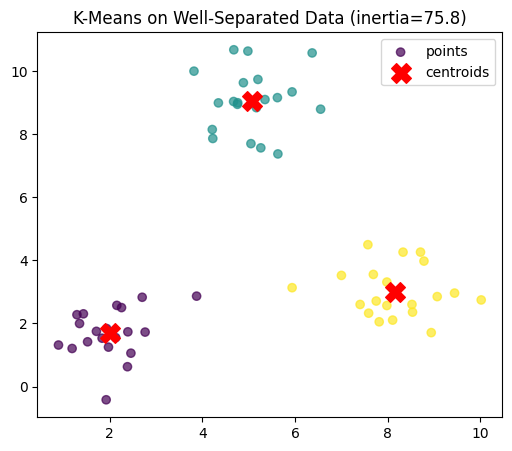

Learned centroids:
 [[2.01 1.7 ]
 [5.08 9.05]
 [8.16 3.01]]
True centers:
 [[2 2]
 [8 3]
 [5 9]]


In [3]:
rng = np.random.default_rng(1515)
true_centers = np.array([[2, 2], [8, 3], [5, 9]])
points = np.vstack([rng.normal(loc=center, scale=0.8, size=(20, 2)) for center in true_centers])

assignments, centroids, inertia = kmeans(points, k=3, seed=1515)

plt.figure(figsize=(6, 5))
plt.scatter(points[:, 0], points[:, 1], c=assignments, cmap='viridis', alpha=0.7, label='points')
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label='centroids')
plt.title(f'K-Means on Well-Separated Data (inertia={inertia:.1f})')
plt.legend()
plt.show()

print("Learned centroids:\n", centroids.round(2))
print("True centers:\n", true_centers)

With three obviously separated blobs, K-Means finds centroids almost exactly matching the true centers, with no labels ever provided. Real data is rarely this clean, though - the next two sections show two genuinely common ways this can go wrong.

## A Real Complication: Feature Scale

Let's cluster scouted teams by playstyle, using the same `climb_rate`/`auto_score` features from `deep_learning_primer/02-value-and-policy-networks.ipynb` - three archetypes: climb specialists, auto specialists, and generalists.

In [4]:
# a fresh, separately-seeded generator for this section, so its numbers stay exactly
# reproducible regardless of how much randomness the earlier synthetic-blobs example used
rng_teams = np.random.default_rng(1515)

n_per_group = 15
climb_specialists = rng_teams.normal(loc=[0.85, 1.5], scale=[0.08, 0.4], size=(n_per_group, 2))
auto_specialists = rng_teams.normal(loc=[0.15, 4.5], scale=[0.08, 0.4], size=(n_per_group, 2))
generalists = rng_teams.normal(loc=[0.5, 2.8], scale=[0.1, 0.4], size=(n_per_group, 2))

teams = np.vstack([climb_specialists, auto_specialists, generalists])
true_playstyle = np.array([0] * n_per_group + [1] * n_per_group + [2] * n_per_group)

assignments_raw, centroids_raw, inertia_raw = kmeans(teams, k=3, seed=1515)
accuracy_raw = max(
    np.mean(np.array([perm[a] for a in assignments_raw]) == true_playstyle)
    for perm in __import__('itertools').permutations(range(3))
)
print(f"Accuracy against the true playstyle groups: {accuracy_raw:.1%}")

Accuracy against the true playstyle groups: 53.3%


That's a disappointing result for data with three genuinely distinct, well-populated groups. One real problem here: `climb_rate` ranges roughly 0-1, while `auto_score` ranges roughly 1.5-4.5 - about 4x the spread. Euclidean distance treats both axes as equally important numerically, so the larger-scale feature (`auto_score`) ends up dominating every distance calculation almost by accident. This is exactly why `ml_primer/03-train-tune-eval.ipynb`'s pipelines used a `StandardScaler` before fitting - any distance-based method needs features on comparable scales to treat them fairly. Let's fix that first, on principle, and see what it does.

In [5]:
teams_scaled = (teams - teams.mean(axis=0)) / teams.std(axis=0)

assignments_scaled, centroids_scaled, inertia_scaled = kmeans(teams_scaled, k=3, seed=1515)
accuracy_scaled = max(
    np.mean(np.array([perm[a] for a in assignments_scaled]) == true_playstyle)
    for perm in __import__('itertools').permutations(range(3))
)
print(f"Accuracy after standardizing features: {accuracy_scaled:.1%}")

Accuracy after standardizing features: 51.1%


Scaling was still the right thing to do - fixing the actual distance-calculation problem is never wasted effort - but the accuracy number alone may not have improved, or could even look slightly worse. That's a real, useful signal that scaling fixed *one* problem while a *second*, separate one is still there: which points the random initialization happened to start from.

## A Second Real Complication: Initialization

Standardizing the features may or may not have been enough on its own, depending on which points the random initialization happened to pick as starting centroids - K-Means has no guarantee of finding the *best* grouping, only a grouping it can no longer improve on from wherever it started. If two initial centroids land in the same true cluster by chance, one true cluster ends up with no centroid of its own, and gets awkwardly split between whichever centroids are nearby instead.

**K-Means++** is the standard fix (it's what `scikit-learn`'s `KMeans` uses by default): instead of picking every initial centroid uniformly at random, pick the first one at random, then pick each subsequent one with probability proportional to its squared distance from the *nearest already-chosen centroid* - deliberately spreading the starting centroids out, rather than leaving it to chance.

In [6]:
def kmeans_plusplus_init(X, k, rng):
    centroids = [X[rng.integers(len(X))]]
    for _ in range(1, k):
        nearest_dist_sq = np.min(
            [np.linalg.norm(X - c, axis=1) ** 2 for c in centroids], axis=0
        )
        probabilities = nearest_dist_sq / nearest_dist_sq.sum()
        next_index = rng.choice(len(X), p=probabilities)
        centroids.append(X[next_index])
    return np.array(centroids)

def kmeans_pp(X, k, n_iters=100, seed=0):
    rng = np.random.default_rng(seed)
    centroids = kmeans_plusplus_init(X, k, rng)
    for _ in range(n_iters):
        distances = np.linalg.norm(X[:, None, :] - centroids[None, :, :], axis=2)
        assignments = np.argmin(distances, axis=1)
        new_centroids = np.array([
            X[assignments == c].mean(axis=0) if np.any(assignments == c) else centroids[c]
            for c in range(k)
        ])
        if np.allclose(new_centroids, centroids):
            break
        centroids = new_centroids
    inertia = np.sum((X - centroids[assignments]) ** 2)
    return assignments, centroids, inertia

assignments_pp, centroids_pp, inertia_pp = kmeans_pp(teams_scaled, k=3, seed=1515)
accuracy_pp = max(
    np.mean(np.array([perm[a] for a in assignments_pp]) == true_playstyle)
    for perm in __import__('itertools').permutations(range(3))
)
print(f"Accuracy with K-Means++ initialization: {accuracy_pp:.1%}")

Accuracy with K-Means++ initialization: 100.0%


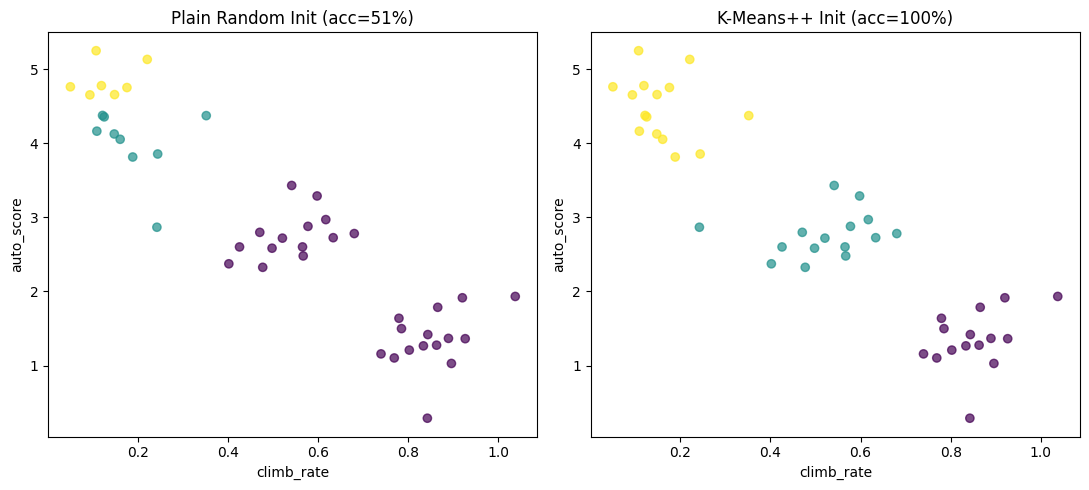

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, assignments_plot, title in [
    (axes[0], assignments_scaled, f'Plain Random Init (acc={accuracy_scaled:.0%})'),
    (axes[1], assignments_pp, f'K-Means++ Init (acc={accuracy_pp:.0%})'),
]:
    ax.scatter(teams[:, 0], teams[:, 1], c=assignments_plot, cmap='viridis', alpha=0.7)
    ax.set_xlabel('climb_rate')
    ax.set_ylabel('auto_score')
    ax.set_title(title)
plt.tight_layout()
plt.show()

## Choosing K: The Elbow Method

Everything above assumed we already knew there were 3 playstyles. In practice, you often don't. One common heuristic: run K-Means for a range of $k$ values, and plot **Inertia** against $k$. Inertia always decreases as $k$ grows (more centroids can always fit the data at least as well), but it tends to drop sharply up to the "real" number of clusters, then level off - the **elbow** in the curve.

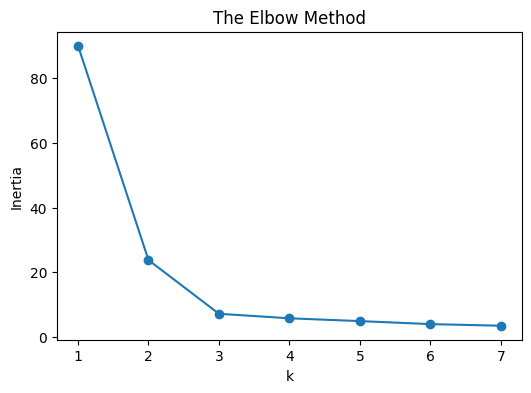

In [8]:
inertias = []
k_values = range(1, 8)
for k in k_values:
    _, _, inertia_k = kmeans_pp(teams_scaled, k=k, seed=1515)
    inertias.append(inertia_k)

plt.figure(figsize=(6, 4))
plt.plot(list(k_values), inertias, 'o-')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('The Elbow Method')
plt.show()

Look for where the curve stops dropping sharply and starts to flatten out - that's usually a defensible choice of $k$, though it's a heuristic, not a guarantee, and real data rarely has as obvious an elbow as this synthetic example.

## Try It Yourself

Add a 4th playstyle archetype to the team data (e.g. a "defense specialist" with its own distinct `climb_rate`/`auto_score` combination), rerun the elbow method across `k=1` through `7`, and check whether the elbow plot actually shows a bend at `k=4` now rather than `k=3`. Then run `kmeans_pp` directly with `k=4` and confirm it recovers all four groups.

In [9]:
# TODO: add a 4th playstyle archetype, rerun the elbow method for k=1..7, and check
# whether the plot bends at k=4; then run kmeans_pp with k=4 directly


## Resources

- Arthur, D. & Vassilvitskii, S. (2007). "k-means++: The Advantages of Careful Seeding." *SODA 2007*. The original paper behind the initialization fix used above (paper).
- [scikit-learn: `KMeans` documentation](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html) - the real, production implementation, which uses k-means++ initialization by default (reference).